In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.optimize import minimize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [ ]:
# Define realistic pulse shapes

def square_envelope(t, power=1.0):
    return np.ones_like(t) * power

def gaussian_envelope(t, power=1.0, sigma_frac=0.2):
    """Gaussian pulse centred on the window."""
    t_c = t[-1] / 2
    sigma = t[-1] * sigma_frac
    env = np.exp(-0.5 * ((t - t_c) / sigma) ** 2)
    return power * env / env.max()

def cosine_ramp_envelope(t, power=1.0, ramp_frac=0.1):
    """Flat-top with raised-cosine rise/fall edges."""
    n = len(t)
    ramp_n = max(1, int(n * ramp_frac))
    ramp = 0.5 * (1 - np.cos(np.pi * np.arange(ramp_n) / ramp_n))
    env = np.ones(n)
    env[:ramp_n] = ramp
    env[-ramp_n:] = ramp[::-1]
    return power * env

def drag_envelope(t, power=1.0, sigma_frac=0.15, alpha=0.5):
    """
    DRAG (Derivative Removal via Adiabatic Gate) envelope.
    Returns (I_env, Q_env) tuple. The Q component suppresses leakage.
    """
    t_c = t[-1] / 2
    sigma = t[-1] * sigma_frac
    gauss = np.exp(-0.5 * ((t - t_c) / sigma) ** 2)
    d_gauss = -(t - t_c) / sigma**2 * gauss
    I_env = power * gauss / gauss.max()
    Q_env = alpha * d_gauss / gauss.max()
    return I_env, Q_env


PULSE_SHAPES = {
    "square":       lambda t, p: square_envelope(t, p),
    "gaussian":     lambda t, p: gaussian_envelope(t, p),
    "cosine_ramp":  lambda t, p: cosine_ramp_envelope(t, p),
}


In [ ]:
# ReadTone class

class ReadTone:
    """
    Single readout tone used in multiplexed readout.
    measure_freq : float  – readout angular frequency
    pulse_shape  : str    – 'square' | 'gaussian' | 'cosine_ramp' | 'drag'
    """

    def __init__(self, measure_freq=6.82e9, n=2000, t=1e-6, power=1,
                 envelope=None, pulse_shape="square"):
        self.freq   = measure_freq
        self.t_end  = t
        self.t      = np.linspace(0, t, n)
        self.power  = power

        if envelope is not None:
            self.envelope = envelope * power
        elif pulse_shape == "drag":
            I_env, Q_env = drag_envelope(self.t, power)
            self.envelope      = I_env
            self.drag_Q_env    = Q_env
        else:
            shape_fn      = PULSE_SHAPES.get(pulse_shape, PULSE_SHAPES["square"])
            self.envelope = shape_fn(self.t, power)

        self.pulse_shape = pulse_shape
        self.pulse = self.envelope * np.cos(measure_freq * self.t)

    def show_pulse(self, only_envelope=True):
        plt.figure(figsize=(7, 2.5))
        if only_envelope:
            plt.plot(self.t * 1e6, self.envelope)
            plt.ylabel("Amplitude")
            plt.title(f"Envelope ({self.pulse_shape})")
        else:
            plt.plot(self.t * 1e6, self.pulse)
            plt.ylabel("Amplitude")
            plt.title(f"Full pulse ({self.pulse_shape})")
        plt.xlabel("Time (µs)")
        plt.tight_layout()
        plt.show()

Testing 'square' pulse shape:


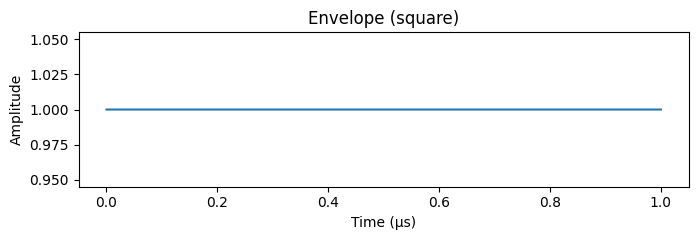

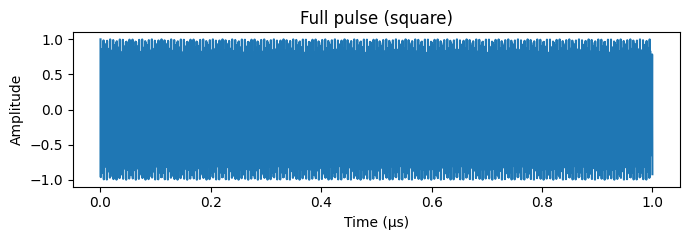

Testing 'gaussian' pulse shape:


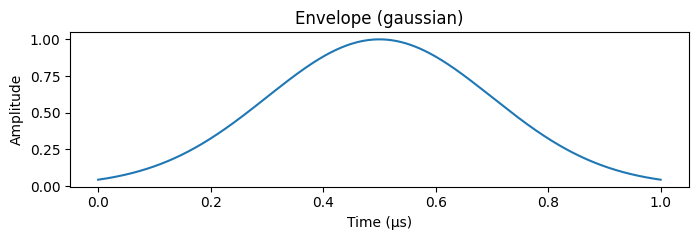

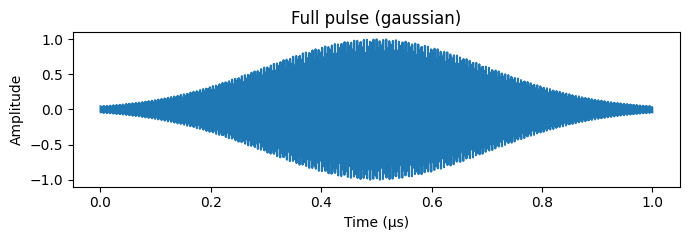

Testing 'cosine_ramp' pulse shape:


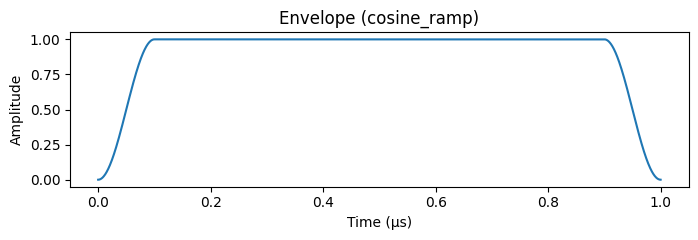

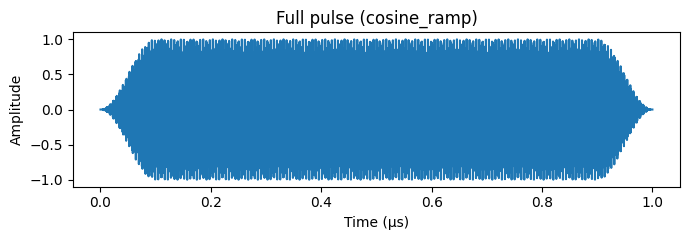

Testing 'drag' pulse shape:


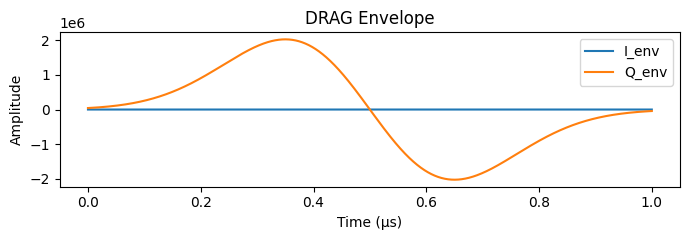

All pulse shapes created and plotted.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Test for square pulse
print("Testing 'square' pulse shape:")
square_pulse = ReadTone(pulse_shape="square", power=1.0)
square_pulse.show_pulse(only_envelope=True)
square_pulse.show_pulse(only_envelope=False)

# Test for gaussian pulse
print("Testing 'gaussian' pulse shape:")
gaussian_pulse = ReadTone(pulse_shape="gaussian", power=1.0, n=2000, t=1e-6)
gaussian_pulse.show_pulse(only_envelope=True)
gaussian_pulse.show_pulse(only_envelope=False)

# Test for cosine_ramp pulse
print("Testing 'cosine_ramp' pulse shape:")
cosine_ramp_pulse = ReadTone(pulse_shape="cosine_ramp", power=1.0, n=2000, t=1e-6)
cosine_ramp_pulse.show_pulse(only_envelope=True)
cosine_ramp_pulse.show_pulse(only_envelope=False)

# Test for drag pulse
print("Testing 'drag' pulse shape:")
drag_pulse = ReadTone(pulse_shape="drag", power=1.0, n=2000, t=1e-6)
plt.figure(figsize=(7, 2.5))
plt.plot(drag_pulse.t * 1e6, drag_pulse.envelope, label='I_env')
plt.plot(drag_pulse.t * 1e6, drag_pulse.drag_Q_env, label='Q_env')
plt.ylabel("Amplitude")
plt.title(f"DRAG Envelope")
plt.xlabel("Time (µs)")
plt.legend()
plt.tight_layout()
plt.show()

assert np.all(square_pulse.envelope == 1.0), "Square pulse envelope is not constant!"
print("All pulse shapes created and plotted.")

In [ ]:
# Multiplexed Resonator

class MultiplexedResonator:
    """
    Multi-resonator + multi-qubit dispersive readout model.

    Parameters
    ----------
    tones   : list[ReadTone]
    omega_r : array [Nr]   – resonator angular frequencies
    kappa   : array [Nr]   – resonator linewidths
    chi     : array [Nr, Nq]  – dispersive shift matrix (can be off-diagonal for crosstalk)
    T1      : array [Nq]   – qubit T1 times
    ex_rate : float or array [Nq]  – state-preparation error probability
    crosstalk_matrix : array [Nr, Nr] or None
        Off-diagonal readout crosstalk: output_r += sum_{r'≠r} crosstalk[r,r'] * a[r']
    """

    def __init__(self, tones, omega_r, kappa, chi, T1=1e-6,
                 decoherence=False, ex_rate=0, crosstalk_matrix=None):
        self.tones      = tones
        self.Nr         = len(omega_r)
        self.Nq         = chi.shape[1]
        self.omega_r    = np.array(omega_r)
        self.kappa      = np.array(kappa)
        self.chi        = np.array(chi)
        self.T1         = np.atleast_1d(np.array(T1, dtype=float))
        self.decoherence = decoherence

        if np.isscalar(ex_rate):
            self.ex_rate = np.full(self.Nq, ex_rate)
        else:
            self.ex_rate = np.array(ex_rate)

        # Readout crosstalk matrix (Nr x Nr); diagonal = 1, off-diag = epsilon
        if crosstalk_matrix is None:
            self.crosstalk = np.eye(self.Nr)
        else:
            self.crosstalk = np.array(crosstalk_matrix)

        self.t  = tones[0].t
        self.dt = self.t[1] - self.t[0]

    def initialize_qubits(self, initial_states):
        self.z = 2 * np.array(initial_states, dtype=float) - 1  # σ_z ∈ {+1, -1}
        for q in range(self.Nq):
            if np.random.rand() < self.ex_rate[q]:
                self.z[q] *= -1

    def _t1_decay_step(self, t_now):
        """Probabilistic T1 decay for each qubit at time t_now."""
        for q in range(self.Nq):
            if self.z[q] == +1:

                # Instantaneous decay probability for this time step
                p_decay = (1.0 / self.T1[q]) * np.exp(-t_now / self.T1[q]) * self.dt
                p_decay = np.clip(p_decay, 0, 1)
                if np.random.rand() < p_decay:
                    self.z[q] = -1.0

    def time_step(self, a, i):
        da = np.zeros(self.Nr, dtype=complex)
        for r in range(self.Nr):
            omega_pulled = self.omega_r[r] + np.sum(self.chi[r, :] * self.z)
            da_r = -(self.kappa[r] / 2
                     + 1j * (self.tones[r].freq - omega_pulled)) * a[r]
            for tone in self.tones:
                da_r += -1j * np.sqrt(self.kappa[r]) * tone.envelope[i]
            da[r] = da_r
        return da

    def trace(self, initial_qubit_states):
        """
        Evolve cavity amplitudes over time.
        Returns a_trace : array [Nt, Nr]  (complex)
        """
        self.initialize_qubits(initial_qubit_states)
        a = np.zeros(self.Nr, dtype=complex)
        a_trace = []

        for i, t_now in enumerate(self.t):
            a_trace.append(a.copy())

            if self.decoherence:
                self._t1_decay_step(t_now)

            da = self.time_step(a, i)
            a += da * self.dt

        a_trace = np.array(a_trace)          # (Nt, Nr)

        # Apply readout crosstalk: each resonator output picks up leakage from others
        if not np.allclose(self.crosstalk, np.eye(self.Nr)):
            a_trace = a_trace @ self.crosstalk.T   # (Nt, Nr) @ (Nr, Nr)

        return a_trace

As seen in the plots, when probing the resonator such that measurement frequency = resonator frequency, all the information regarding the state of the qubit is within the phase and no information is carried by the amplitude.

Tracing cavity amplitudes for ground and excited states...


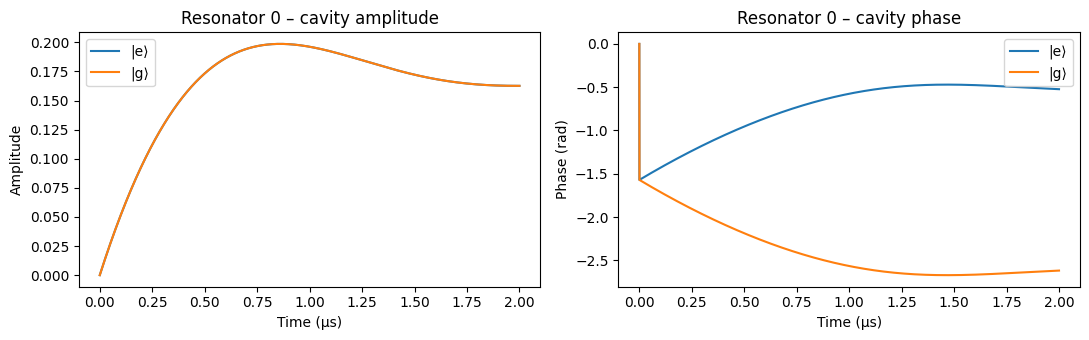

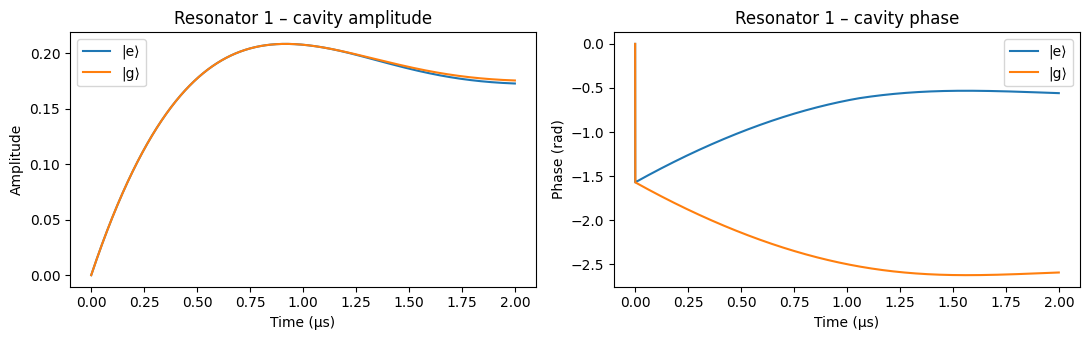

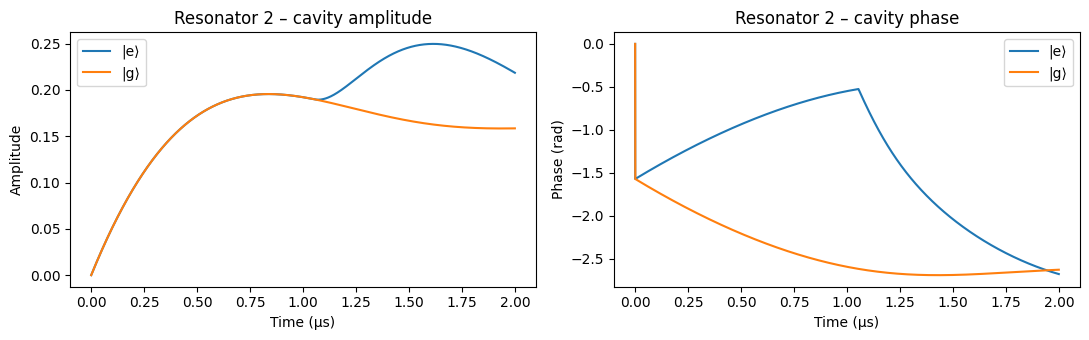

MultiplexedResonator class check complete.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters ----
Nr           = 3 # Number of resonators
Nq           = Nr # Number of qubits, assumed equal to Nr for simplicity
t_measurement = 2e-6

kappas   = 2 * np.pi * np.array([550e3, 550e3, 550e3]) # Resonator linewidths

omega_rs = 2 * np.pi * np.array([6.065e9, 6.065e9, 6.065e9]) # Resonator angular frequencies
omega_rs = 2 * np.pi * np.array([6.0e9, 6.1e9, 6.2e9])
T1s      = np.array([50e-6, 50e-6, 50e-6]) # Qubit T1 times
chi_vals = np.pi * np.array([921.139e3, 850e3, 950e3]) # Dispersive shifts
chis     = np.diag(chi_vals)

# Small off-diagonal readout crosstalk between resonators (1 %)
crosstalk = np.eye(Nr)
crosstalk[0, 1] = crosstalk[1, 0] = 0.01
crosstalk[1, 2] = crosstalk[2, 1] = 0.01

n = 5000 # Number of time steps for the pulse
envelope = np.ones(n) # Simple square envelope for testing
tones = [
    ReadTone(measure_freq=omega_rs[r], n=n, t=t_measurement,
             envelope=envelope, power=100, pulse_shape="square")
    for r in range(Nr)
]

# Initialize the MultiplexedResonator
resonator = MultiplexedResonator(
    tones=tones,
    omega_r=omega_rs,
    kappa=kappas,
    chi=chis,
    T1=T1s,
    decoherence=True,
    ex_rate=0.03,
    crosstalk_matrix=crosstalk,
)

print("Tracing cavity amplitudes for ground and excited states...")
# Trace cavity amplitudes for all qubits in excited state
a_exc = resonator.trace([1] * Nq)
# Trace cavity amplitudes for all qubits in ground state
a_gnd = resonator.trace([0] * Nq)

# Plotting results for each resonator
for r in range(Nr):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

    # Plot amplitude
    ax1.plot(resonator.t * 1e6, np.abs(a_exc[:, r]), label="|e⟩")
    ax1.plot(resonator.t * 1e6, np.abs(a_gnd[:, r]), label="|g⟩")
    ax1.set_title(f"Resonator {r} – cavity amplitude")
    ax1.set_xlabel("Time (µs)")
    ax1.set_ylabel("Amplitude")
    ax1.legend()

    # Plot phase
    ax2.plot(resonator.t * 1e6, np.angle(a_exc[:, r]), label="|e⟩")
    ax2.plot(resonator.t * 1e6, np.angle(a_gnd[:, r]), label="|g⟩")
    ax2.set_title(f"Resonator {r} – cavity phase")
    ax2.set_xlabel("Time (µs)")
    ax2.set_ylabel("Phase (rad)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

print("MultiplexedResonator class check complete.")

In [ ]:
# Simiplified Noise Model


def _create_noise(signal_length, dt, f_readout, t_end):
    """
    Simplified two-stage amplifier noise referred to the resonator output:
      Stage 1 – TWPA (quantum-limited + small added noise, G=20 dB)
      Stage 2 – HEMT (T=4 K, G=40 dB)

    Returns (noise_array, total_voltage_gain).
    """
    k_B = 1.380649e-23
    h   = 6.62607015e-34
    R   = 50.0

    nyquist   = 1.0 / (2.0 * dt)
    B_signal  = min(1.0 / t_end, nyquist)

    # TWPA: vacuum noise + ~0.5 K added
    T_twpa  = h * f_readout / (2 * k_B) + 0.5
    G_twpa  = 10 ** (20 / 20)          # voltage gain (10× for 20 dB power)

    # HEMT
    T_hemt  = 4.0
    G_hemt  = 10 ** (40 / 20)          # voltage gain

    def johnson(T, B):
        return np.sqrt(4 * k_B * T * R * B)

    sigma_twpa = johnson(T_twpa, B_signal)
    sigma_hemt = johnson(T_hemt, nyquist)

    noise  = np.random.normal(0, sigma_twpa,  signal_length)          # TWPA referred to input
    noise += np.random.normal(0, sigma_hemt,  signal_length) / G_twpa  # HEMT referred back

    total_gain = G_twpa * G_hemt
    return noise, total_gain

Testing _create_noise function:
Generated noise array shape: (5000,)
Calculated total voltage gain: 1000.00


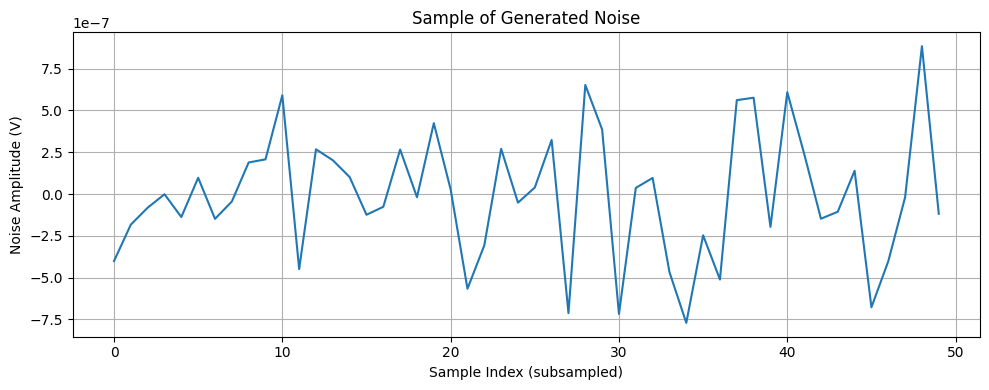

Noise mean: -2.34e-09
Noise standard deviation: 3.69e-07
_create_noise function test complete.


In [ ]:
# Test the _create_noise function
print("Testing _create_noise function:")

signal_length = 5000
dt = 2e-6 / 5000  # Corresponds to a 2us measurement with 5000 points
f_readout = 6.065e9  # Example readout frequency
t_end = 2e-6

noise, total_gain = _create_noise(signal_length, dt, f_readout, t_end)

print(f"Generated noise array shape: {noise.shape}")
print(f"Calculated total voltage gain: {total_gain:.2f}")

# Plot a segment of the noise to visualize it
plt.figure(figsize=(10, 4))
plt.plot(noise[::100]) # Plotting every 100th point for better visualization if signal_length is large
plt.title("Sample of Generated Noise")
plt.xlabel("Sample Index (subsampled)")
plt.ylabel("Noise Amplitude (V)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Basic statistical check
print(f"Noise mean: {np.mean(noise):.2e}")
print(f"Noise standard deviation: {np.std(noise):.2e}")

print("_create_noise function test complete.")

In [ ]:

class ReadoutChain:
    """
    Converts a resonator field trace into a single (I, Q) point per resonator.

    Key changes vs. original
    ------------------------
    * Simplified two-stage noise (TWPA + HEMT).
    * T1-mid-measurement effect flows naturally from MultiplexedResonator.trace().
    * Crosstalk handled by MultiplexedResonator.

    """

    def __init__(self, resonator, tones, delta=1e6, lo_noise=0.0,
                 t_delay=0.0, homodyne=False):
        self.resonator = resonator
        self.tones     = tones
        self.delta     = delta
        self.t_delay   = t_delay
        self.lo_noise  = lo_noise
        self.homodyne  = homodyne
        self.w_lo      = np.array([tone.freq - delta for tone in tones])

    def get_iq(self, initial_state=None):
        if initial_state is None:
            initial_state = [0] * self.resonator.Nq

        a = self.resonator.trace(initial_state)   # (Nt, Nr)
        a = a.T                                    # (Nr, Nt)
        Nr, Nt = a.shape

        output_field = (
            a * np.sqrt(2 * np.pi * 6.626e-34 * 50
                        * self.resonator.omega_r[:, None]
                        * self.resonator.kappa[:, None])
        )

        I = np.zeros(Nr)
        Q = np.zeros(Nr)

        for r in range(Nr):
            I_raw = np.real(output_field[r])
            Q_raw = np.imag(output_field[r])

            tone     = self.resonator.tones[r]
            f_ro     = tone.freq / (2 * np.pi)
            noise_I, gain = _create_noise(len(I_raw), self.resonator.dt, f_ro, tone.t_end)
            noise_Q, _    = _create_noise(len(Q_raw), self.resonator.dt, f_ro, tone.t_end)

            I_sig = (I_raw + noise_I) * gain
            Q_sig = (Q_raw + noise_Q) * gain

            # Demodulate: rotate by -delta*t to get baseband
            t  = self.resonator.t
            lo = np.exp(-1j * self.delta * t)
            bb = (I_sig + 1j * Q_sig) * lo

            mask = (t >= self.t_delay) & (t <= tone.t_end)
            I[r] = np.mean(np.real(bb[mask]))
            Q[r] = np.mean(np.imag(bb[mask]))

        return I, Q

In [ ]:
# Shot generation and Multi-Class LDA (Classification)

def on_off_exp(readchain, shots=200):
    """
    Collect IQ shots for all-ground and all-excited states.
    Returns data_gnd, data_ex  each of shape (shots, Nr, 2).
    """
    Nr = readchain.resonator.Nr
    Nq = readchain.resonator.Nq
    data_gnd = np.zeros((shots, Nr, 2))
    data_ex  = np.zeros((shots, Nr, 2))

    print("Ground state shots …")
    for i in tqdm(range(shots)):
        # Runs the full physics simulation (cavity ring-up, T1 decay, noise, demodulation) and returns a single (I,Q) point per resonator
        I, Q = readchain.get_iq(initial_state=[0] * Nq)
        data_gnd[i] = np.column_stack((I, Q))

    print("Excited state shots …")
    for i in tqdm(range(shots)):
        I, Q = readchain.get_iq(initial_state=[1] * Nq)
        data_ex[i] = np.column_stack((I, Q))

    return data_gnd, data_ex


def multi_state_exp(readchain, shots=200):
    """
    Three-class experiment: ground |0⟩, excited |1⟩, and a mixed |0,1,...⟩ pattern.
    Returns a dict { label: data(shots, Nr, 2) }.
    """
    Nr = readchain.resonator.Nr
    Nq = readchain.resonator.Nq
    states = {
        "g": [0] * Nq,
        "e": [1] * Nq,
        "mix": [i % 2 for i in range(Nq)],
    }
    results = {}
    for label, state in states.items():
        print(f"State |{label}⟩ shots …")
        data = np.zeros((shots, Nr, 2))
        for i in tqdm(range(shots)):
            I, Q = readchain.get_iq(initial_state=state)
            data[i] = np.column_stack((I, Q))
        results[label] = data
    return results


def fidelity_multi(data_gnd, data_ex, r=0, data_extra=None):
    """
    LDA classification on resonator r.

    data_gnd, data_ex : (shots, Nr, 2)
    data_extra        : optional third class, same shape
    Plots IQ scatter + decision boundary + projection histogram.
    Returns classification accuracy.
    """
    shots = data_gnd.shape[0]

    X = np.vstack([data_gnd[:, r, :], data_ex[:, r, :]])
    y = np.array([0] * shots + [1] * shots)
    labels = {0: "|g⟩", 1: "|e⟩"}

    if data_extra is not None:
        X = np.vstack([X, data_extra[:, r, :]])
        y = np.concatenate([y, [2] * data_extra.shape[0]])
        labels[2] = "|mix⟩"

    lda = LDA()
    lda.fit(X, y)
    y_pred = lda.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"Resonator {r}  LDA accuracy: {acc:.3f}")

    # ---- IQ scatter + decision boundary ----
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    pad = 0.1 * max(x_max - x_min, y_max - y_min)
    xx, yy = np.meshgrid(
        np.linspace(x_min - pad, x_max + pad, 300),
        np.linspace(y_min - pad, y_max + pad, 300),
    )
    Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    colors = ["#4C9BE8", "#E8664C", "#50C878"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.contourf(xx, yy, Z, alpha=0.18, cmap=plt.cm.RdYlBu)
    for cls, lbl in labels.items():
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1],
                   label=lbl, alpha=0.7, s=18, color=colors[cls])
    ax.set_xlabel("I  (V)")
    ax.set_ylabel("Q  (V)")
    ax.set_title(f"Resonator {r} – IQ clusters  (acc={acc:.3f})")
    ax.legend()

    # ---- Projection histogram ----
    ax = axes[1]
    proj = lda.decision_function(X)
    if proj.ndim == 1:
        proj = proj[:, None]
    for cls, lbl in labels.items():
        mask = y == cls
        p = proj[mask, 0] if proj.shape[1] > 1 else proj[mask, 0]
        ax.hist(p, bins=30, alpha=0.55, label=lbl, color=colors[cls])
    ax.axvline(0, color="k", ls="--", lw=1.2)
    ax.set_xlabel("LDA projection")
    ax.set_ylabel("Counts")
    ax.set_title(f"Resonator {r} – readout distributions")
    ax.legend()

    plt.tight_layout()
    plt.show()
    return acc

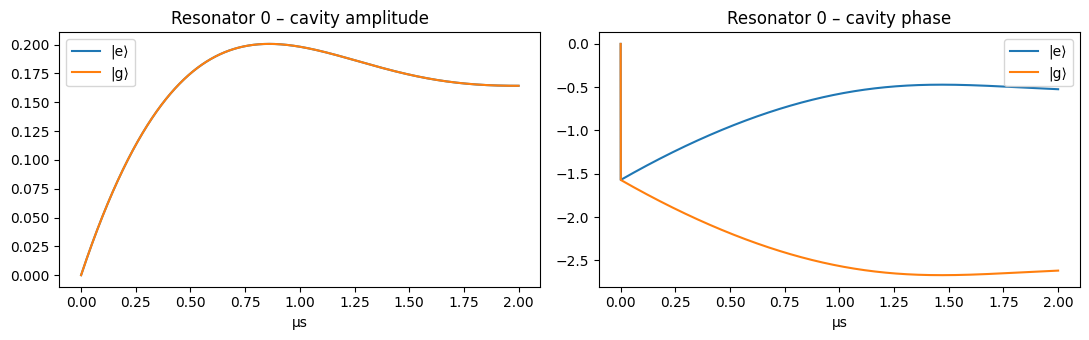

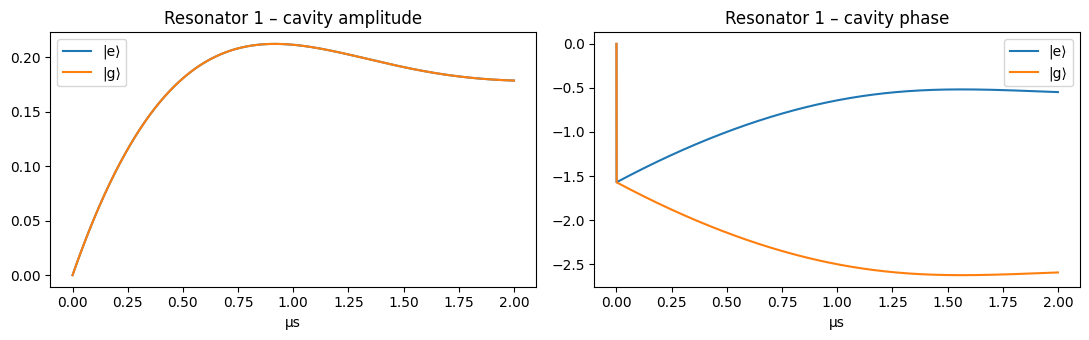

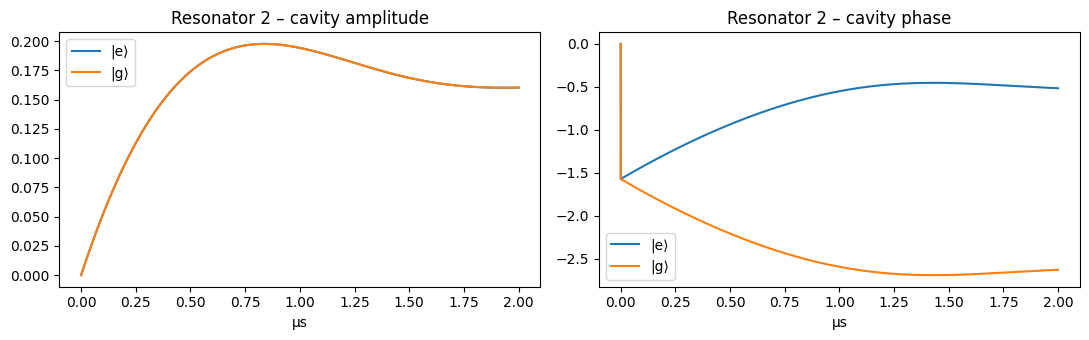

Ground state shots …


100%|██████████| 30/30 [00:09<00:00,  3.27it/s]


Excited state shots …


100%|██████████| 30/30 [00:13<00:00,  2.25it/s]


Resonator 0  LDA accuracy: 0.967


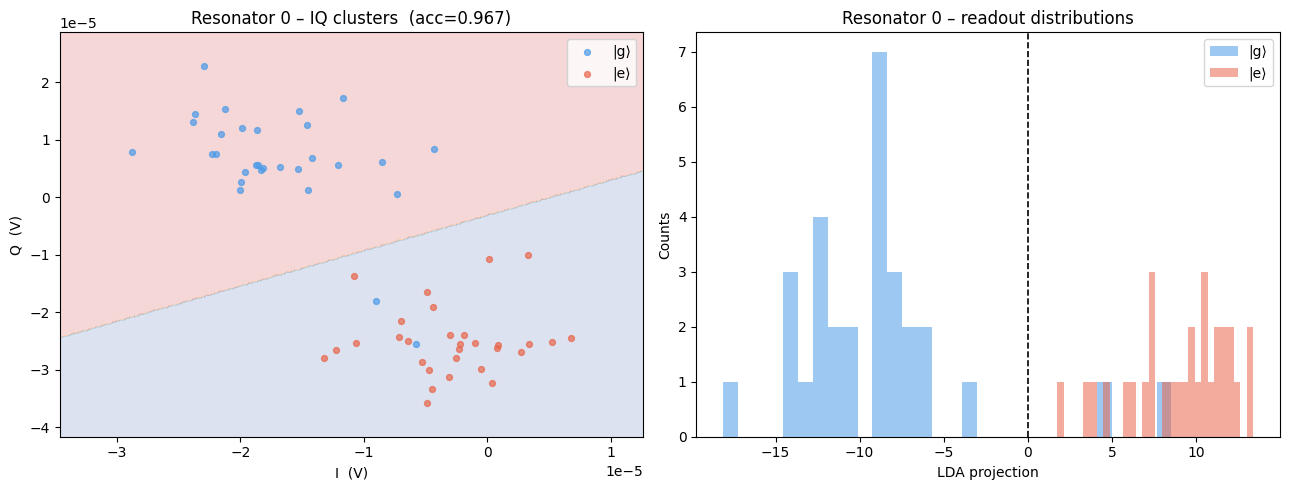

  Resonator 0 accuracy: 0.967
Resonator 1  LDA accuracy: 0.933


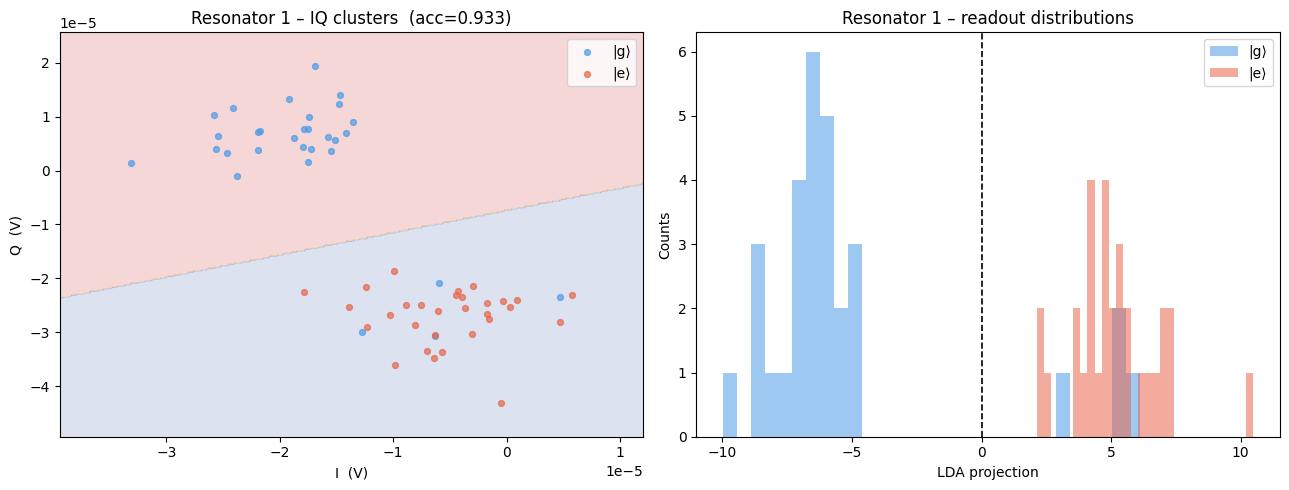

  Resonator 1 accuracy: 0.933
Resonator 2  LDA accuracy: 0.933


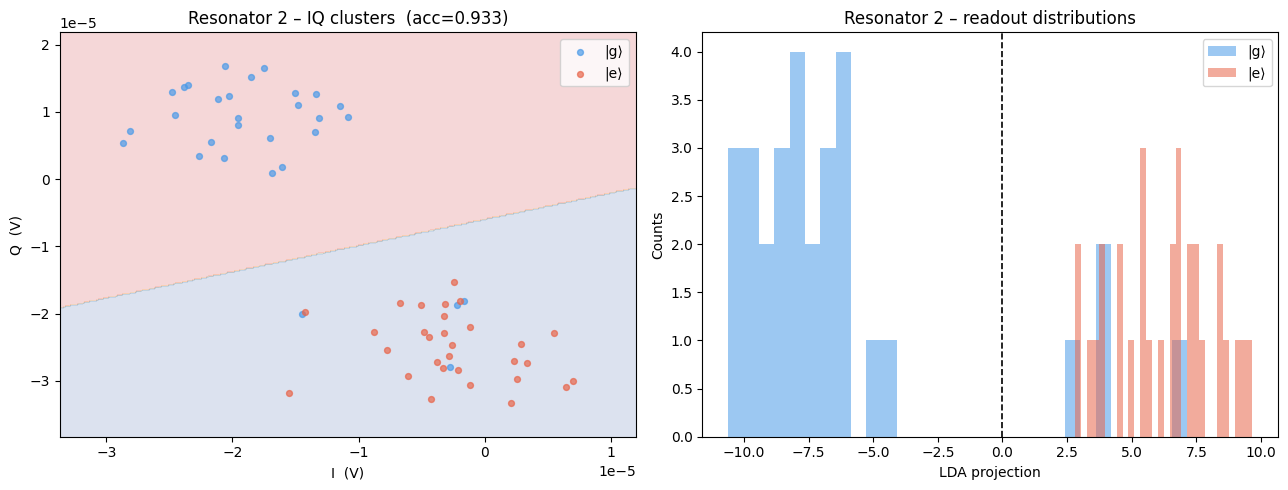

  Resonator 2 accuracy: 0.933
State |g⟩ shots …


100%|██████████| 30/30 [00:09<00:00,  3.33it/s]


State |e⟩ shots …


100%|██████████| 30/30 [00:13<00:00,  2.29it/s]


State |mix⟩ shots …


100%|██████████| 30/30 [00:09<00:00,  3.04it/s]


Resonator 0  LDA accuracy: 0.711


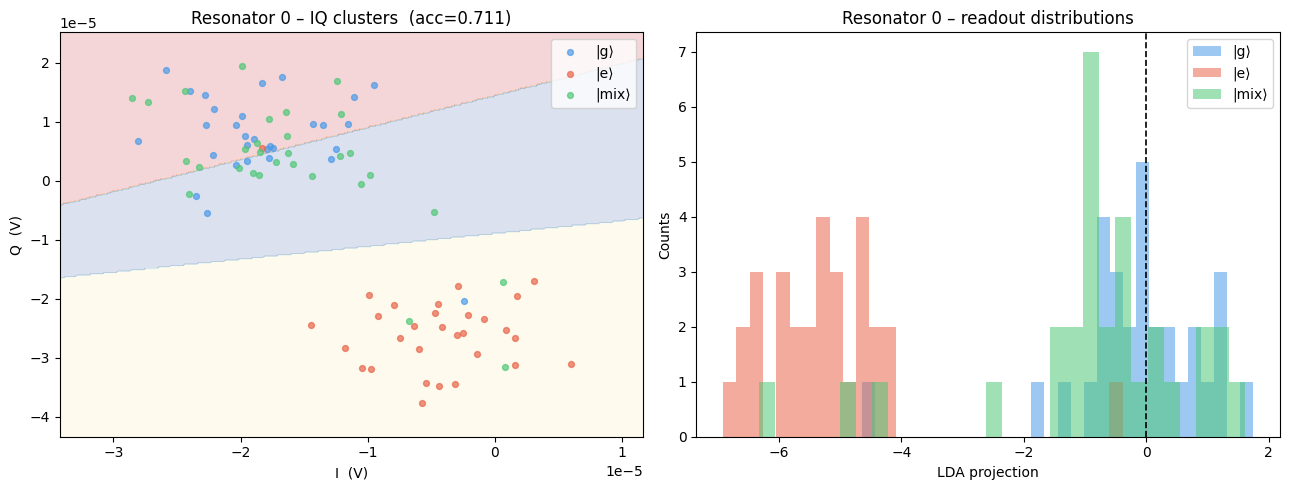

In [ ]:

# Basiline run of entire tone --> resonator --> readoutchain
if __name__ == "__main__":

    # ---- Parameters ----
    Nr           = 3
    Nq           = Nr
    n            = 5000
    t_measurement = 2e-6

    kappas   = 2 * np.pi * np.array([550e3, 550e3, 550e3])
    omega_rs = 2 * np.pi * np.array([6.065e9, 6.065e9, 6.065e9])
    omega_rs = 2 * np.pi * np.array([6.0e9, 6.1e9, 6.2e9])
    T1s      = np.array([50e-6, 50e-6, 50e-6])
    chi_vals = np.pi * np.array([921.139e3, 850e3, 950e3])
    chis     = np.diag(chi_vals)

    # Small off-diagonal readout crosstalk between resonators (1 %)
    crosstalk = np.eye(Nr)
    crosstalk[0, 1] = crosstalk[1, 0] = 0.02
    crosstalk[1, 2] = crosstalk[2, 1] = 0.02

    envelope = np.ones(n)
    tones = [
        ReadTone(measure_freq=omega_rs[r], n=n, t=t_measurement,
                 envelope=envelope, power=100, pulse_shape="cosine_ramp")
        for r in range(Nr)
    ]

    resonator = MultiplexedResonator(
        tones=tones,
        omega_r=omega_rs,
        kappa=kappas,
        chi=chis,
        T1=T1s,
        decoherence=True,
        ex_rate=0.05,
        crosstalk_matrix=crosstalk,
    )

    readchain = ReadoutChain(
        resonator=resonator,
        tones=tones,
        delta=1e6,
        lo_noise=0.0,
        t_delay=0.0,
    )

    # ---- Cavity field traces ----
    a_exc = resonator.trace([1] * Nq)
    a_gnd = resonator.trace([0] * Nq)
    for r in range(Nr):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
        ax1.plot(resonator.t * 1e6, np.abs(a_exc[:, r]), label="|e⟩")
        ax1.plot(resonator.t * 1e6, np.abs(a_gnd[:, r]), label="|g⟩")
        ax1.set_title(f"Resonator {r} – cavity amplitude"); ax1.set_xlabel("µs")
        ax1.legend()
        ax2.plot(resonator.t * 1e6, np.angle(a_exc[:, r]), label="|e⟩")
        ax2.plot(resonator.t * 1e6, np.angle(a_gnd[:, r]), label="|g⟩")
        ax2.set_title(f"Resonator {r} – cavity phase"); ax2.set_xlabel("µs")
        ax2.legend()
        plt.tight_layout(); plt.show()

    # ---- IQ shots ----
    shots = 30
    data_gnd, data_ex = on_off_exp(readchain, shots=shots)

    for r in range(Nr):
        acc = fidelity_multi(data_gnd, data_ex, r=r)
        print(f"  Resonator {r} accuracy: {acc:.3f}")

    # ---- 3-class demo (one resonator) ----
    three_class = multi_state_exp(readchain, shots=shots)
    fidelity_multi(
        three_class["g"], three_class["e"], r=0,
        data_extra=three_class["mix"]
    )

The LDA projection plot collapses the Nr×2 dimensional IQ space down to 2D for visualization. With 3 qubits you have 8 states — you want to see 8 distinct clouds. If two clouds overlap completely it means those two states are genuinely indistinguishable given your current readout parameters.

100%|██████████| 20/20 [00:14<00:00,  1.36it/s]


100%|██████████| 20/20 [00:06<00:00,  3.03it/s]


100%|██████████| 20/20 [00:08<00:00,  2.44it/s]


100%|██████████| 20/20 [00:07<00:00,  2.70it/s]


100%|██████████| 20/20 [00:08<00:00,  2.47it/s]


100%|██████████| 20/20 [00:08<00:00,  2.34it/s]


100%|██████████| 20/20 [00:07<00:00,  2.79it/s]


100%|██████████| 20/20 [00:09<00:00,  2.12it/s]



Joint 3-qubit classification accuracy: 0.900


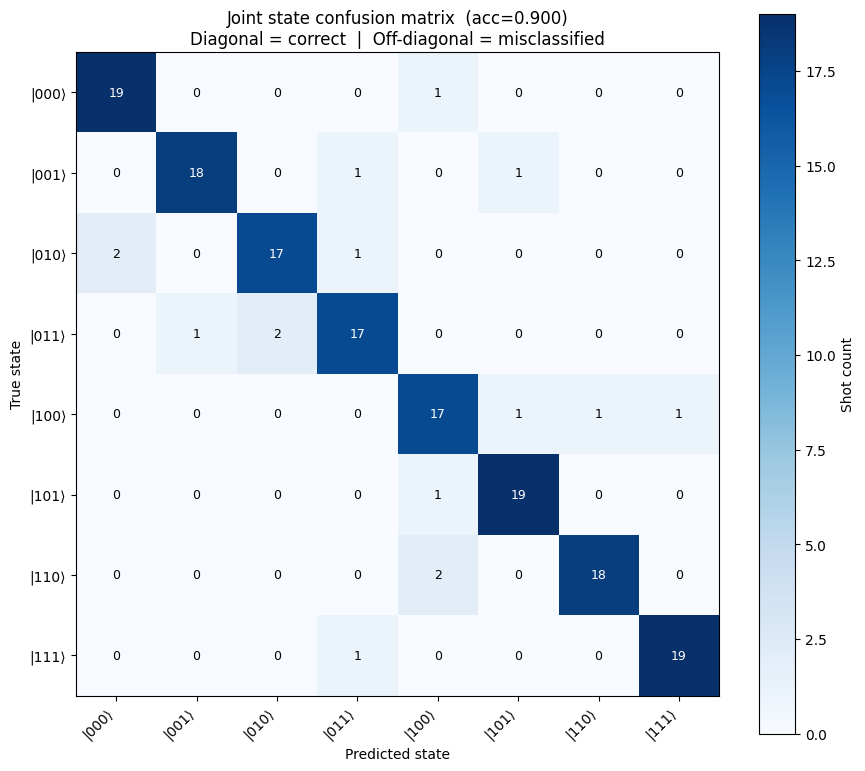

Joint classification accuracy: 0.900


In [ ]:
def joint_state_classification(readchain, shots=100):
    """
    Joint classification of the full multi-qubit state.
    Each shot is a feature vector of length Nr*2  (I0,Q0, I1,Q1, ..., INr,QNr).
    Labels are bitstrings: '000', '001', '010', etc.
    """
    from itertools import product

    Nr = readchain.resonator.Nr
    Nq = readchain.resonator.Nq

    # Collect shots for every computational basis state
    all_states = list(product([0, 1], repeat=Nq))   # 2^Nq states
    X_all, y_all, label_map = [], [], {}

    for state_idx, state in enumerate(all_states):
        label = ''.join(str(b) for b in state)      # e.g. (1,0,1) → '101'
        label_map[state_idx] = f"|{''.join(str(b) for b in state)}⟩"
        print(f"Collecting shots for |{label}⟩ …")
        for _ in tqdm(range(shots)):
            I, Q = readchain.get_iq(initial_state=list(state))
            # Interleave: [I0, Q0, I1, Q1, ...]
            vec = np.array([val for pair in zip(I, Q) for val in pair])
            X_all.append(vec)
            y_all.append(state_idx)

    X = np.array(X_all)          # (2^Nq * shots,  Nr*2)
    y = np.array(y_all)

    # ── Fit joint LDA ──
    lda = LDA()
    lda.fit(X, y)
    y_pred = lda.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\nJoint {Nq}-qubit classification accuracy: {acc:.3f}")

    # ── Confusion matrix ──
    n_states = len(all_states)
    conf = np.zeros((n_states, n_states), dtype=int)
    for true, pred in zip(y, y_pred):
        conf[true, pred] += 1

    tick_labels = [label_map[i] for i in range(n_states)]
    fig, ax = plt.subplots(figsize=(n_states + 1, n_states))
    im = ax.imshow(conf, cmap="Blues")
    ax.set_xticks(range(n_states)); ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_yticks(range(n_states)); ax.set_yticklabels(tick_labels)
    ax.set_xlabel("Predicted state")
    ax.set_ylabel("True state")
    ax.set_title(f"Joint state confusion matrix  (acc={acc:.3f})\n"
                  "Diagonal = correct  |  Off-diagonal = misclassified")
    for i in range(n_states):
        for j in range(n_states):
            ax.text(j, i, conf[i, j], ha="center", va="center",
                    color="white" if conf[i, j] > shots * 0.5 else "black", fontsize=9)
    plt.colorbar(im, ax=ax, label="Shot count")
    plt.tight_layout()
    plt.show()

    return acc, conf, label_map

acc_joint, conf, label_map = joint_state_classification(readchain, shots=20)
print(f"Joint classification accuracy: {acc_joint:.3f}")

Future Work - Pulse Optimizer to maximize the IQ separation for each resonator (given a resonator index)